# Voyage Analytics

Github Link - https://github.com/aniket010011/Intern-Projects/blob/main/VoyageAnalytics(temp).ipynb

## Problem Description

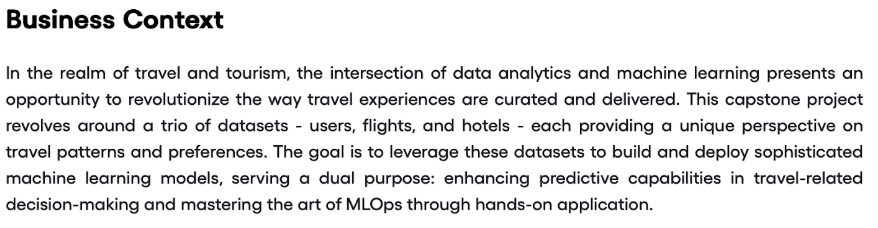

Build an intelligent travel analytics system that predicts travel behavior and recommends hotels or flights using machine learning, and deploy it using an MLOps pipeline.

## Objectives

Building ML models using travel data (users, flights, hotels)

Creating recommendations or predictions

Deploying and productionizing the ML system using MLOps

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import mlflow
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Loading and merging Datasets

In [2]:
users = pd.read_csv("users.csv")
hotels = pd.read_csv("hotels.csv")
flights = pd.read_csv("flights.csv")

df = flights.merge(hotels, on=["travelCode","userCode"])
df = df.merge(users, left_on="userCode", right_on="code")

Feature Engineering

In [3]:
df['date_x'] = pd.to_datetime(df['date_x'])
df['date_y'] = pd.to_datetime(df['date_y'])

In [4]:
df["travel_month"] = df["date_x"].dt.month
df["travel_day"] = df["date_x"].dt.day

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81104 entries, 0 to 81103
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   travelCode    81104 non-null  int64         
 1   userCode      81104 non-null  int64         
 2   from          81104 non-null  object        
 3   to            81104 non-null  object        
 4   flightType    81104 non-null  object        
 5   price_x       81104 non-null  float64       
 6   time          81104 non-null  float64       
 7   distance      81104 non-null  float64       
 8   agency        81104 non-null  object        
 9   date_x        81104 non-null  datetime64[ns]
 10  name_x        81104 non-null  object        
 11  place         81104 non-null  object        
 12  days          81104 non-null  int64         
 13  price_y       81104 non-null  float64       
 14  total         81104 non-null  float64       
 15  date_y        81104 non-null  dateti

In [6]:
df.head()

,travelCode,userCode,from,to,flightType,price_x,time,distance,agency,date_x,...,price_y,total,date_y,code,company,name_y,gender,age,travel_month,travel_day
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,...,313.02,1252.08,2019-09-26,0,4You,Roy Braun,male,21,9,26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,...,313.02,1252.08,2019-09-26,0,4You,Roy Braun,male,21,9,30
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,...,263.41,526.82,2019-10-10,0,4You,Roy Braun,male,21,10,10
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,2019-10-12,...,263.41,526.82,2019-10-10,0,4You,Roy Braun,male,21,10,12
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,2019-11-14,...,263.41,790.23,2019-11-14,0,4You,Roy Braun,male,21,11,14


Check for Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

Check for Missing Values

In [8]:
df.isna().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price_x,0
time,0
distance,0
agency,0
date_x,0


## Exploratory Data Analysis

Age Distribution

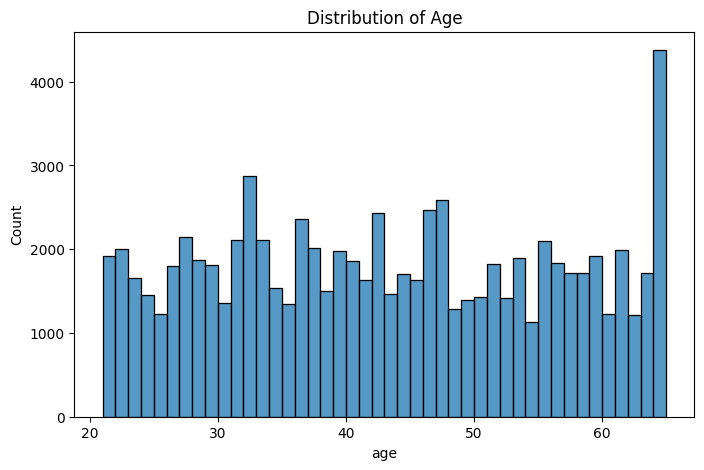

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'])
plt.title("Distribution of Age")
plt.show()

shows how user ages are distributed in the travel dataset. From the chart, we can derive the following insights:
The distribution appears relatively even between ages 25–60.
There is no single dominant age peak, meaning usage is spread across many age groups.

Flight Price and Distance

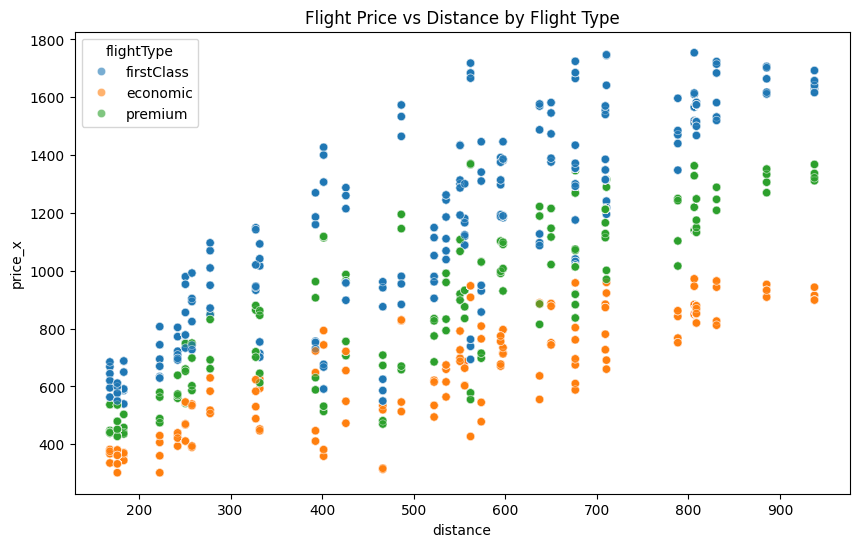

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="distance",
    y="price_x",
    hue="flightType",
    alpha=0.6
)

plt.title("Flight Price vs Distance by Flight Type")
plt.show()

This scatter plot shows the relationship between flight distance and ticket price and indicate the following:
Longer flights tend to be more expensive
Prices vary significantly
Distance alone cannot fully explain price


Flight Type Distribution

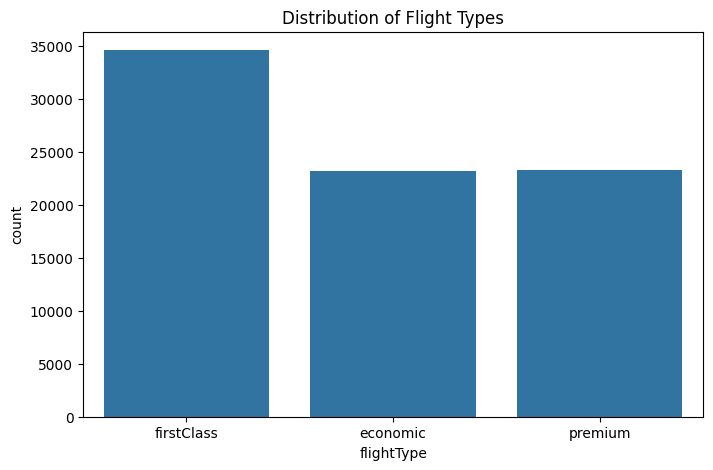

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="flightType",data=df)
plt.title("Distribution of Flight Types")
plt.show()

This bar chart shows how many bookings were made for each flight class in the dataset and indicate the following:
From the chart, First Class flights have the highest count (~34,000) compared to other flight types
A large portion of travelers in this dataset appear to prefer high-end travel options
Both Economic and Premium classes have around ~23,000 bookings, which is noticeably lower than First Class but similar to each other

Top Destinations

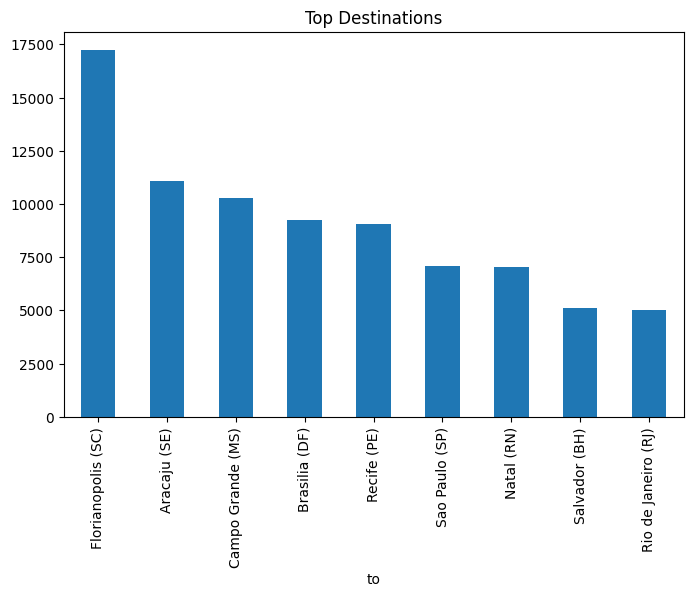

In [12]:
plt.figure(figsize=(8,5))
df['to'].value_counts().plot(kind='bar')
plt.title("Top Destinations")
plt.show()

This bar chart shows the most frequently traveled destination cities in the dataset and indicate the following:
From the chart, Florianopolis (SC) has the highest number of trips with 17,000, significantly higher than other cities
The next most popular destinations are Aracaju (SE) with 11,000 trips and Campo Grande (MS) with 10,000 trips

Hotel Price distribution

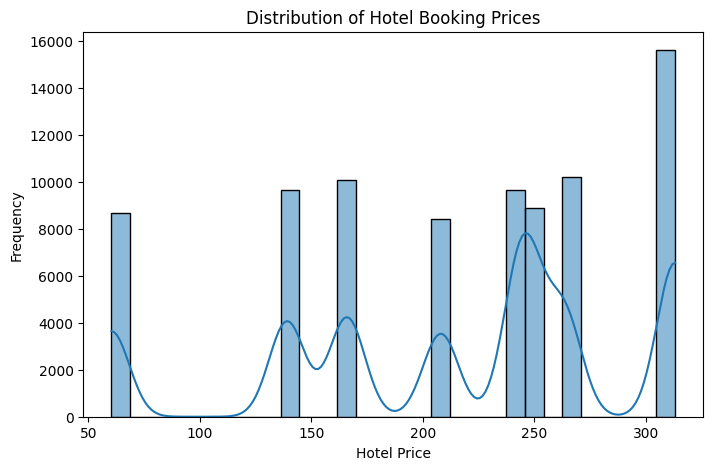

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['price_y'],
    bins=30,
    kde=True
)

plt.title("Distribution of Hotel Booking Prices")
plt.xlabel("Hotel Price")
plt.ylabel("Frequency")

plt.show()

This chart shows the frequency distribution of hotel booking prices in the dataset, along with a KDE curve that highlights the overall price trend and indicates the following:
Hotel prices in the dataset range all the way from 60 to 310
This indicates that travelers in the dataset choose different accommodation tiers depending on their preferences or budgets
Most travelers tend to book mid-range hotels rather than extremely cheap or very expensive ones

Correlation Heatmap

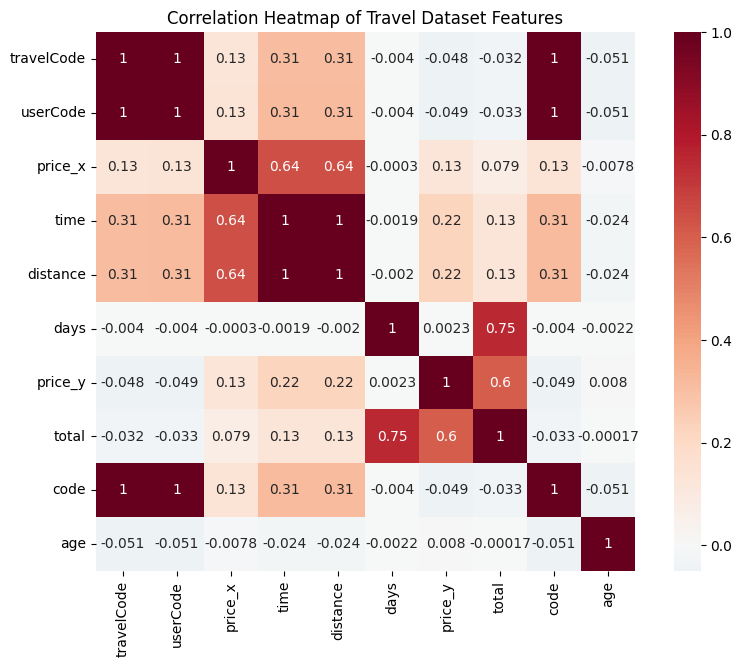

In [15]:
plt.figure(figsize=(10,7))

# Select only numerical columns
num_df = df.select_dtypes(include=['int64','float64'])

# Compute correlation matrix
corr_matrix = num_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Travel Dataset Features")

plt.show()

The correlation heatmap shows strong positive relationships between flight distance and flight price, as well as between distance and flight duration. This indicates that longer routes tend to have higher travel costs and longer travel times. Additionally, hotel price shows a strong relationship with total travel expenditure. These correlations confirm that travel cost is largely influenced by route characteristics and accommodation pricing.

## Feature Selection and Model Building

In [16]:
X = df
X = X.drop(columns=["total", "travelCode", "userCode", "code", "name_x", "name_y"])

In [17]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [18]:
preprocessor = ColumnTransformer([
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
])

In [19]:
print(num_cols)
print(cat_cols)

['price_x', 'time', 'distance', 'days', 'price_y', 'age']
['from', 'to', 'flightType', 'agency', 'place', 'company', 'gender']


In [20]:
pipeline = Pipeline([
    ("preprocessing",preprocessor),
    ("model",XGBRegressor())
])

Train Test Split

In [21]:
X = df[num_cols + cat_cols]
y = df["total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['price_x', 'time',
                                                   'distance', 'days',
                                                   'price_y', 'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'flightType',
                                                   'agency', 'place', 'company',
                                                   'gender'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsa...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

Model Evaluation

In [22]:
pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 3.7734356156409266e-09
R2 Score: 0.999999999999963


Visualizing Predictions

Text(0, 0.5, 'Predicted')

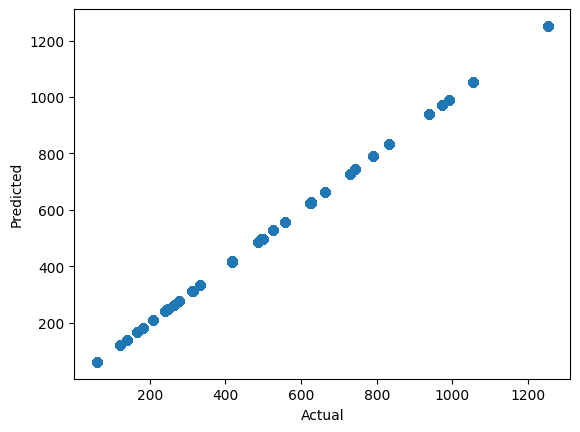

In [23]:
plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [24]:
with mlflow.start_run():

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    rmse = mean_squared_error(y_test, pred) ** 0.5

    mlflow.log_metric("rmse", rmse)

    mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="travel_model"
    )

2026/03/08 14:04:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
